In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [7]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape", X.shape)
print("Classes:", np.unique(y))


Dataset Shape (569, 30)
Classes: [0 1]


In [11]:
X_train, X_test, y_train,y_test = train_test_split(
   X,
    y,
    test_size= 0.2,
    random_state = 42,
    stratify = y
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
mle_model = LogisticRegression(
    penalty = None,
    max_iter = 5000,
    random_state = 42
)
mle_model.fit(X_train, y_train)

y_pred_mle = mle_model.predict(X_test)

In [20]:
map_l2 = LogisticRegression(
    penalty = 'l2',
    C = 1.0,
    solver = 'lbfgs',
    max_iter = 5000,
    random_state = 42
)

map_l2.fit(X_train, y_train)

y_pred_l2 = map_l2.predict(X_test)

In [22]:
map_l1 = LogisticRegression(
    penalty = 'l1',
    C = 1.0,
    solver = 'liblinear',
    max_iter = 5000,
    random_state = 42
)

map_l1.fit(X_train, y_train)

y_pred_l1 = map_l1.predict(X_test)

In [33]:
def evaluate(model_name, y_true, y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy: ",accuracy_score(y_true, y_pred))
    print("Precision: ",precision_score(y_true, y_pred))
    print("Recall: ", recall_score(y_true, y_pred))
    print("F1 Score :",f1_score(y_true, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))
    print("---"*15)
    

In [34]:
evaluate("MLE", y_test, y_pred_mle)

evaluate("L2", y_test, y_pred_l2)

evaluate("L1", y_test, y_pred_l1)


MLE
Accuracy:  0.9210526315789473
Precision:  0.9701492537313433
Recall:  0.9027777777777778
F1 Score : 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]
---------------------------------------------

L2
Accuracy:  0.9824561403508771
Precision:  0.9861111111111112
Recall:  0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]
---------------------------------------------

L1
Accuracy:  0.9912280701754386
Precision:  0.9863013698630136
Recall:  1.0
F1 Score : 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]
---------------------------------------------


In [36]:
print("Number of Zero Coefficients:")

print("MLE       :",np.sum(mle_model.coef_[0] == 0))

print("Map L2    :",np.sum(map_l2.coef_[0] == 0))

print("Map L1    :",np.sum(map_l1.coef_[0] == 0))

Number of Zero Coefficients:
MLE       : 0
Map L2    : 0
Map L1    : 14


In [42]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

models = [
    ("MLE" , mle_model, y_pred_mle),
    ("MAP L2" , map_l2, y_pred_l2),
    ("MAP L1", map_l1, y_pred_l1)
    ]

for name ,model, pred in models:
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]
print(results)

dfnlkndf;v

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


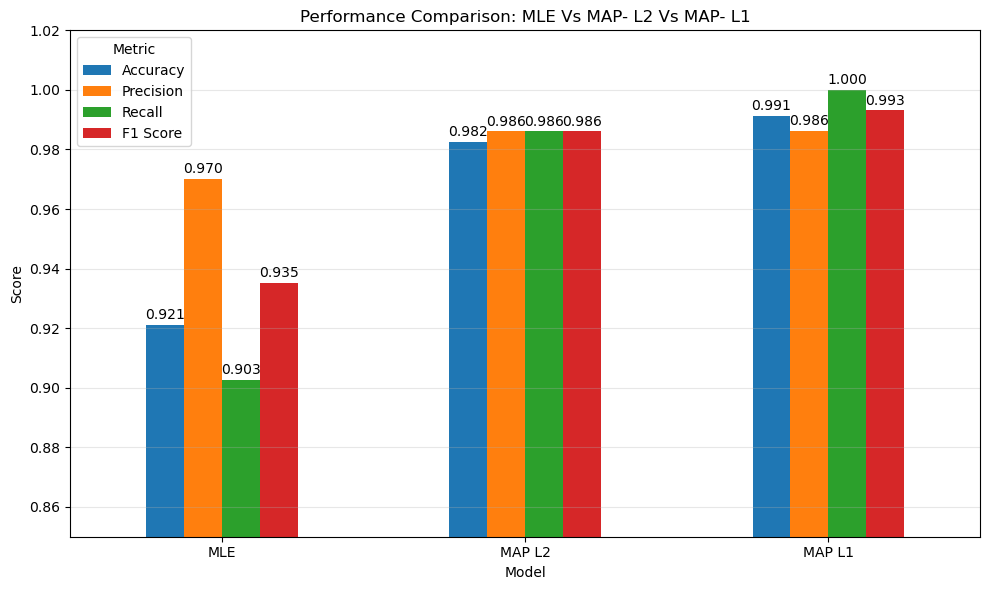

In [54]:
ax = results.set_index("Model").plot(
    kind = "bar",
    figsize = (10, 6)
)

plt.title("Performance Comparison: MLE Vs MAP- L2 Vs MAP- L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.02)

plt.xticks(rotation = 0)
plt.legend(title= "Metric")
plt.grid(axis ="y", alpha = 0.3)

#Show values in bars
for containers in ax.containers:
    ax.bar_label(containers, fmt = "%.3f", padding = 2)

plt.tight_layout()
plt.show()

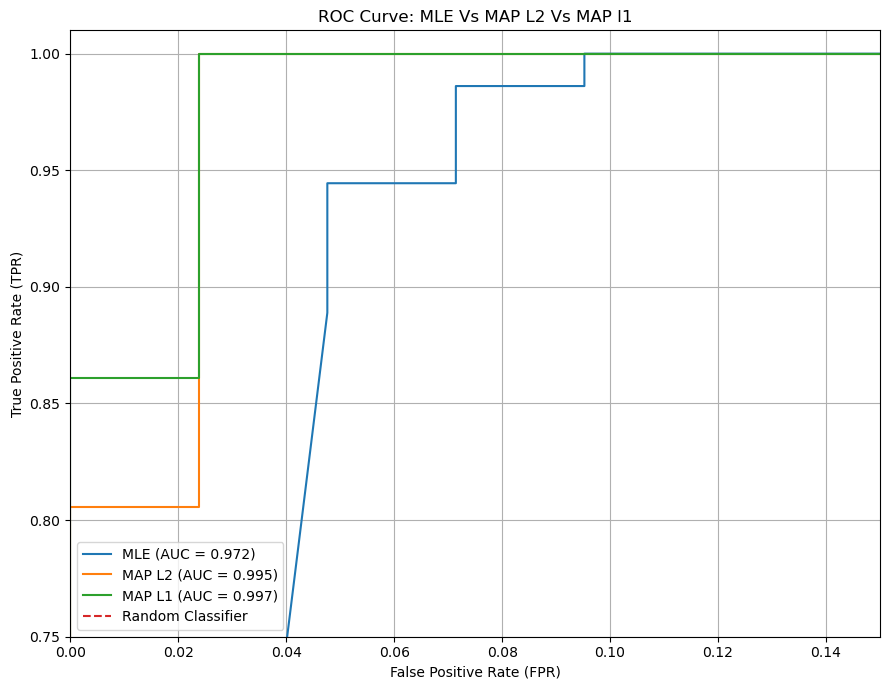

In [67]:
plt.figure(figsize = (9,7))

for name, model, pred in models:
    #predicted probability for positive class
    y_prob = model.predict_proba(X_test)[:,1]

    #Calculate ROC Values
    fpr,tpr,threshold = roc_curve(y_test, y_prob)

    #Calculate AUC
    roc_auc = auc(fpr, tpr)

    #Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label = f"{name} (AUC = {roc_auc:.3f})"
    )

#Random Classifier Reference Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle = '--',
    label = "Random Classifier"
)

#Zoom into the useful region
plt.xlim(0, 0.15)
plt.ylim(0.75, 1.01)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE Vs MAP L2 Vs MAP l1")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()